# ⚡ Notebook 06: Module 4 — Support Vector Machines
## Linear, Polynomial, RBF Kernels, Decision Boundaries, SVR & Multiclass Classification

In [1]:
import sys
import os
import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix

from src.utils import load_numpy, save_model
from src.evaluation_metrics import compute_all_metrics, plot_confusion_matrix
from src.svm_models import (
    train_svm_classifier,
    train_svr,
    train_multiclass_svm,
    get_support_vectors_info,
    evaluate_svr_model
)

X_train = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "X_train.npy"))
X_test = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "X_test.npy"))

y_train_bin = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "y_train_binary.npy"))
y_test_bin = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "y_test_binary.npy"))

y_train_multi = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "y_train_multi.npy"))
y_test_multi = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "y_test_multi.npy"))

y_train_sev = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "y_train_severity.npy"))
y_test_sev = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "y_test_severity.npy"))

sub_idx = np.random.choice(len(X_train), 15000, replace=False)
X_sub = X_train[sub_idx]
y_sub_bin = y_train_bin[sub_idx]
y_sub_multi = y_train_multi[sub_idx]
y_sub_sev = y_train_sev[sub_idx]

📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\X_train.npy | Shape: (125973, 122)
📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\X_test.npy | Shape: (22544, 122)
📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\y_train_binary.npy | Shape: (125973,)
📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\y_test_binary.npy | Shape: (22544,)
📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\y_train_multi.npy | Shape: (125973,)
📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\y_test_multi.npy | Shape: (22544,)
📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\y_train_severity.npy | Shape: (125973,)
📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\y_test_severity.npy | Shape: (22544,)


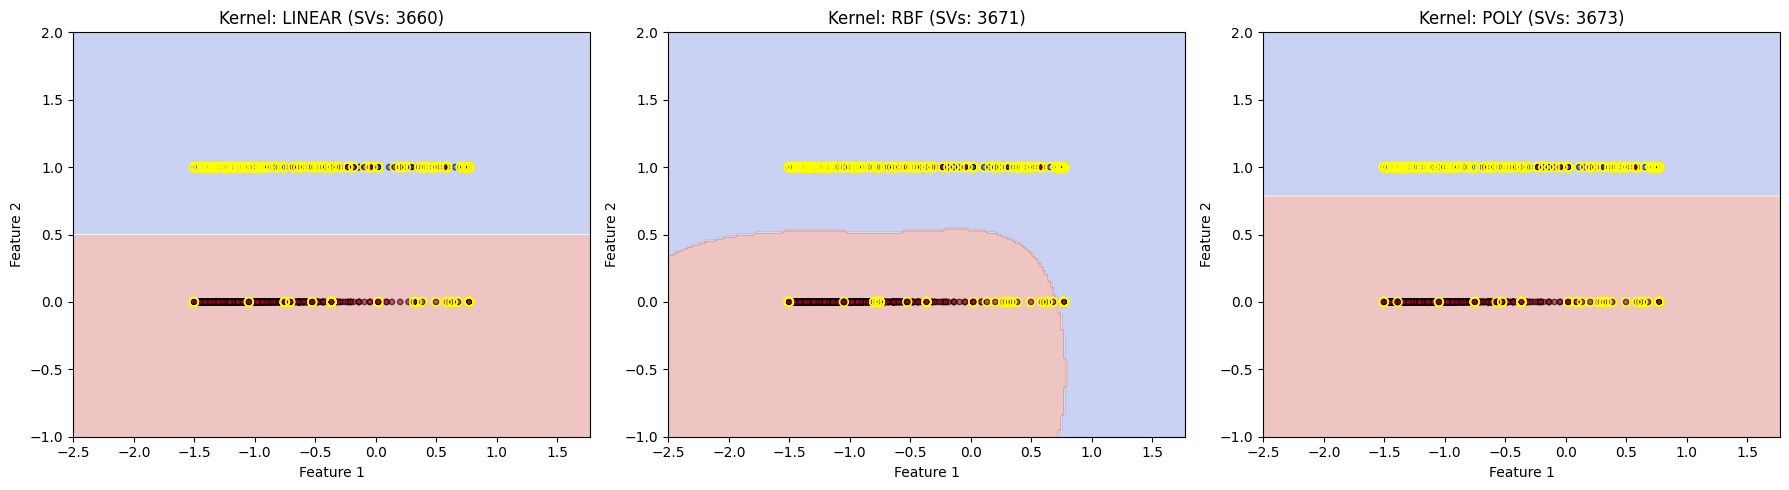

In [2]:
from sklearn.feature_selection import SelectKBest, f_classif

selector_2d = SelectKBest(f_classif, k=2)
X_sub_2d = selector_2d.fit_transform(X_sub, y_sub_bin)

kernels = ["linear", "rbf", "poly"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x_min, x_max = X_sub_2d[:, 0].min() - 1, X_sub_2d[:, 0].max() + 1
y_min, y_max = X_sub_2d[:, 1].min() - 1, X_sub_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

for idx, k in enumerate(kernels):
    clf = train_svm_classifier(X_sub_2d, y_sub_bin, kernel=k, C=1.0)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    axes[idx].contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    axes[idx].scatter(X_sub_2d[:, 0], X_sub_2d[:, 1], c=y_sub_bin, cmap="coolwarm", edgecolors="k", s=15, alpha=0.6)
    axes[idx].scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=40, facecolors="none", edgecolors="yellow", linewidths=1.2)
    axes[idx].set_title(f"Kernel: {k.upper()} (SVs: {len(clf.support_vectors_)})")
    axes[idx].set_xlabel("Feature 1")
    axes[idx].set_ylabel("Feature 2")

plt.tight_layout()
fig.savefig(os.path.join(PROJECT_ROOT, "plots", "module4", "support_vectors_visualization.png"), dpi=150)
plt.show()

💾 Model saved: d:\WebDev\Network_Intrusion_Detection\models\saved_models\svm_linear.pkl
💾 Model saved: d:\WebDev\Network_Intrusion_Detection\models\saved_models\svm_rbf.pkl
💾 Model saved: d:\WebDev\Network_Intrusion_Detection\models\saved_models\svm_poly.pkl


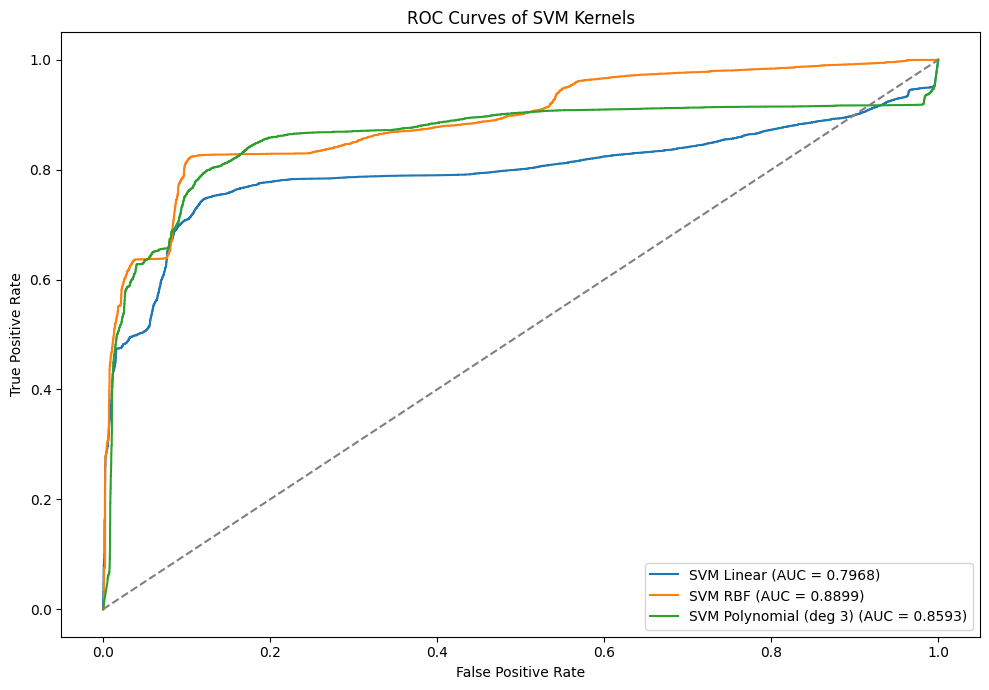

                    Model  Accuracy  Precision    Recall  F1-Score     Kappa  \
0              SVM Linear  0.753549   0.916447  0.623938  0.742420  0.521985   
1                 SVM RBF  0.771780   0.962241  0.623549  0.756726  0.559555   
2  SVM Polynomial (deg 3)  0.750355   0.965499  0.582249  0.726424  0.521480   

   Sensitivity  Specificity       AUC  Total Support Vectors  
0     0.623938     0.924828  0.796780                    951  
1     0.623549     0.967666  0.889860                    943  
2     0.582249     0.972505  0.859321                   1255  


In [3]:
svm_linear = train_svm_classifier(X_sub, y_sub_bin, kernel="linear", C=1.0, probability=True)
save_model(svm_linear, os.path.join(PROJECT_ROOT, "models", "saved_models", "svm_linear.pkl"))

svm_rbf = train_svm_classifier(X_sub, y_sub_bin, kernel="rbf", C=1.0, gamma="scale", probability=True)
save_model(svm_rbf, os.path.join(PROJECT_ROOT, "models", "saved_models", "svm_rbf.pkl"))

svm_poly = train_svm_classifier(X_sub, y_sub_bin, kernel="poly", degree=3, C=1.0, probability=True)
save_model(svm_poly, os.path.join(PROJECT_ROOT, "models", "saved_models", "svm_poly.pkl"))

svm_models = {
    "SVM Linear": svm_linear,
    "SVM RBF": svm_rbf,
    "SVM Polynomial (deg 3)": svm_poly
}

svm_metrics_list = []
fig, ax = plt.subplots(figsize=(10, 7))

for name, model in svm_models.items():
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    
    metrics = compute_all_metrics(y_test_bin, preds, probs)
    sv_info = get_support_vectors_info(model)
    
    svm_metrics_list.append({
        "Model": name,
        "Accuracy": metrics["accuracy"],
        "Precision": metrics["precision"],
        "Recall": metrics["recall"],
        "F1-Score": metrics["f1"],
        "Kappa": metrics["kappa"],
        "Sensitivity": metrics["sensitivity"],
        "Specificity": metrics["specificity"],
        "AUC": metrics["auc"],
        "Total Support Vectors": sv_info["total_support_vectors"]
    })
    
    fpr, tpr, _ = roc_curve(y_test_bin, probs)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {metrics['auc']:.4f})")

ax.plot([0, 1], [0, 1], color="grey", linestyle="--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves of SVM Kernels")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(os.path.join(PROJECT_ROOT, "plots", "module4", "kernel_comparison.png"), dpi=150)
plt.show()

svm_results_df = pd.DataFrame(svm_metrics_list)
print(svm_results_df)
svm_results_df.to_csv(os.path.join(PROJECT_ROOT, "results", "svm_kernels_results.csv"), index=False)

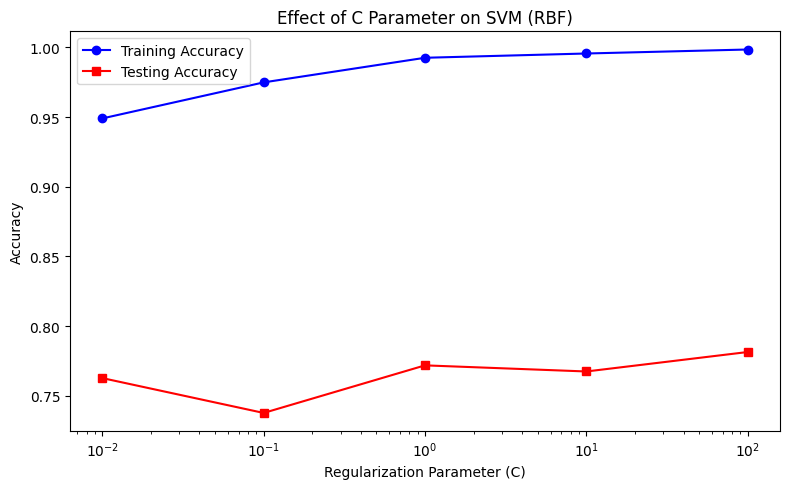

In [4]:
c_values = [0.01, 0.1, 1.0, 10.0, 100.0]
c_train_scores = []
c_test_scores = []

for c in c_values:
    clf = train_svm_classifier(X_sub, y_sub_bin, kernel="rbf", C=c)
    c_train_scores.append(clf.score(X_sub, y_sub_bin))
    c_test_scores.append(clf.score(X_test, y_test_bin))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(c_values, c_train_scores, marker="o", label="Training Accuracy", color="blue")
ax.plot(c_values, c_test_scores, marker="s", label="Testing Accuracy", color="red")
ax.set_xscale("log")
ax.set_xlabel("Regularization Parameter (C)")
ax.set_ylabel("Accuracy")
ax.set_title("Effect of C Parameter on SVM (RBF)")
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(PROJECT_ROOT, "plots", "module4", "svm_decision_boundary_rbf.png"), dpi=150)
plt.show()

💾 Model saved: d:\WebDev\Network_Intrusion_Detection\models\saved_models\svr_model.pkl
                mse      rmse       mae        r2
SVR (RBF)  0.065565  0.256057  0.160226  0.408566


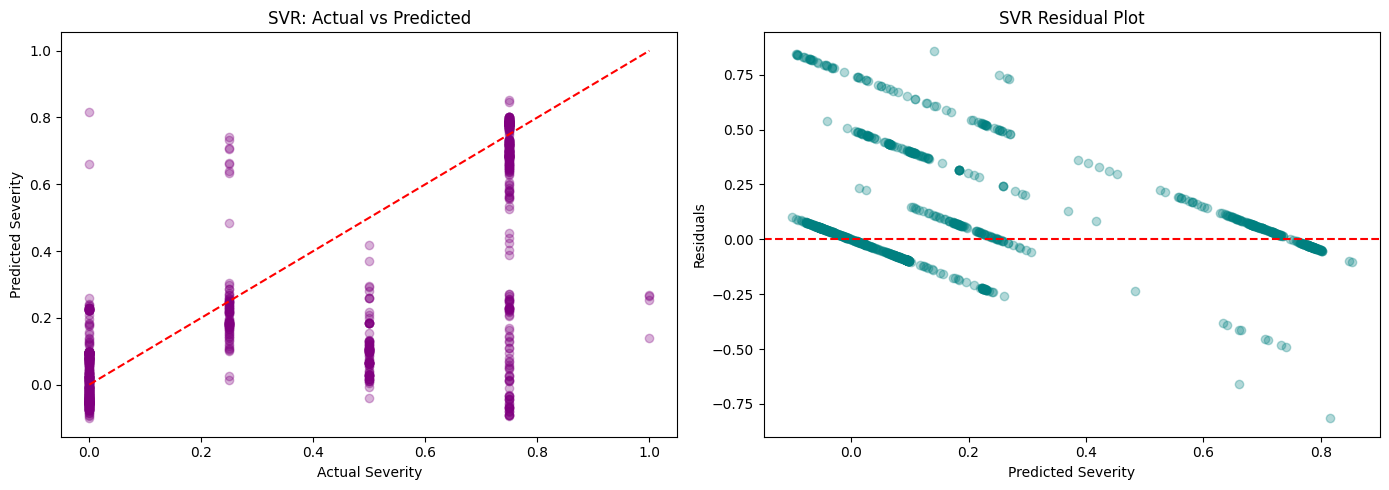

In [5]:
svr = train_svr(X_sub, y_sub_sev, kernel="rbf", C=1.0, epsilon=0.1)
save_model(svr, os.path.join(PROJECT_ROOT, "models", "saved_models", "svr_model.pkl"))

svr_metrics = evaluate_svr_model(svr, X_test, y_test_sev)
print(pd.DataFrame([svr_metrics], index=["SVR (RBF)"]))

svr_preds = svr.predict(X_test)
residuals = y_test_sev - svr_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_sev[:1000], svr_preds[:1000], alpha=0.3, color="purple")
axes[0].plot([0, 1], [0, 1], color="red", linestyle="--")
axes[0].set_xlabel("Actual Severity")
axes[0].set_ylabel("Predicted Severity")
axes[0].set_title("SVR: Actual vs Predicted")

axes[1].scatter(svr_preds[:1000], residuals[:1000], alpha=0.3, color="teal")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted Severity")
axes[1].set_ylabel("Residuals")
axes[1].set_title("SVR Residual Plot")

plt.tight_layout()
fig.savefig(os.path.join(PROJECT_ROOT, "plots", "module4", "svr_results.png"), dpi=150)
plt.show()

💾 Model saved: d:\WebDev\Network_Intrusion_Detection\models\saved_models\svm_multiclass_ovr.pkl
💾 Model saved: d:\WebDev\Network_Intrusion_Detection\models\saved_models\svm_multiclass_ovo.pkl
Multiclass OvR Accuracy: 0.7415
Multiclass OvO Accuracy: 0.7415
📂 Model loaded: d:\WebDev\Network_Intrusion_Detection\models\encoders\label_encoder_multi.pkl


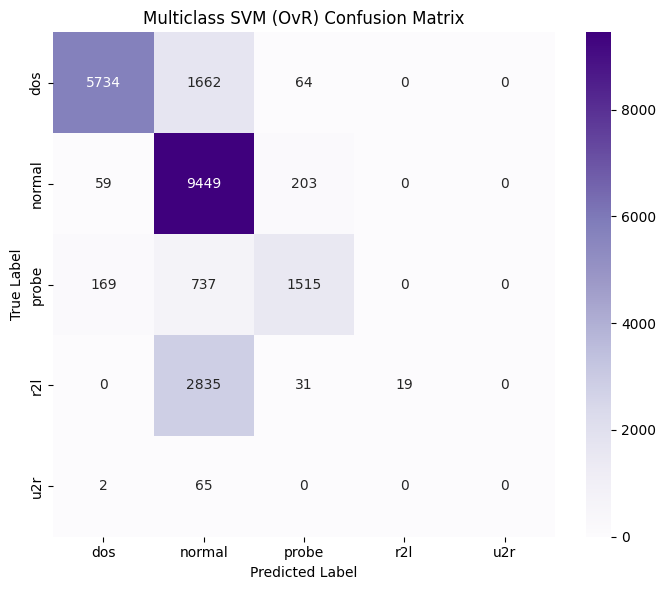

In [6]:
svm_ovr = train_multiclass_svm(X_sub, y_sub_multi, decision_function_shape="ovr")
save_model(svm_ovr, os.path.join(PROJECT_ROOT, "models", "saved_models", "svm_multiclass_ovr.pkl"))

svm_ovo = train_multiclass_svm(X_sub, y_sub_multi, decision_function_shape="ovo")
save_model(svm_ovo, os.path.join(PROJECT_ROOT, "models", "saved_models", "svm_multiclass_ovo.pkl"))

multi_preds_ovr = svm_ovr.predict(X_test)
multi_preds_ovo = svm_ovo.predict(X_test)

print(f"Multiclass OvR Accuracy: {np.mean(multi_preds_ovr == y_test_multi):.4f}")
print(f"Multiclass OvO Accuracy: {np.mean(multi_preds_ovo == y_test_multi):.4f}")

from src.utils import load_model
le_multi = load_model(os.path.join(PROJECT_ROOT, "models", "encoders", "label_encoder_multi.pkl"))
class_labels = list(le_multi.classes_)

cm_multi = confusion_matrix(y_test_multi, multi_preds_ovr)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_multi, annot=True, fmt="d", cmap="Purples", xticklabels=class_labels, yticklabels=class_labels, ax=ax)
ax.set_title("Multiclass SVM (OvR) Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
fig.savefig(os.path.join(PROJECT_ROOT, "plots", "module4", "multiclass_svm_confusion.png"), dpi=150)
plt.show()